# 1. Download and load the data. Perform the initial exploration and cleaning.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib


In [2]:
from huggingface_hub import hf_hub_download

# Download remote csv i guess


df_train_raw = pd.read_csv(r"https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/train.csv")
df_test_raw = pd.read_csv(r"https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/test.csv")

print('Train samples:', len(df_train_raw))
print('Test samples:', len(df_test_raw))

Train samples: 10003
Test samples: 3080


In [3]:
df_train_raw.head()

,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


In [4]:
#basic checks 
print('Train samples:', len(df_train_raw))
print('Test samples:', len(df_test_raw))
print('Number of classes:', df_train_raw['category'].nunique())
print('Label range:', df_train_raw['category'].min(), '-', df_train_raw['category'].max())
print()
print('Data types:')
display(df_train_raw.dtypes)

Train samples: 10003
Test samples: 3080
Number of classes: 77
Label range: Refund_not_showing_up - wrong_exchange_rate_for_cash_withdrawal

Data types:


,0
text,object
category,object


In [7]:
# i think this is the best i can do as typecasting for now, i wil lsee later if categories in both datasets are in line with each other 
df_train_raw['category'] = df_train_raw['category'].astype('category')
df_test_raw['category'] = df_test_raw['category'].astype('category')
df_train_raw['text'] = df_train_raw['text'].astype('string')
df_test_raw['text'] = df_test_raw['text'].astype('string')

print(df_train_raw['category'].dtype)
print(df_train_raw['category'].cat.categories)

category
Index(['Refund_not_showing_up', 'activate_my_card', 'age_limit',
       'apple_pay_or_google_pay', 'atm_support', 'automatic_top_up',
       'balance_not_updated_after_bank_transfer',
       'balance_not_updated_after_cheque_or_cash_deposit',
       'beneficiary_not_allowed', 'cancel_transfer', 'card_about_to_expire',
       'card_acceptance', 'card_arrival', 'card_delivery_estimate',
       'card_linking', 'card_not_working', 'card_payment_fee_charged',
       'card_payment_not_recognised', 'card_payment_wrong_exchange_rate',
       'card_swallowed', 'cash_withdrawal_charge',
       'cash_withdrawal_not_recognised', 'change_pin', 'compromised_card',
       'contactless_not_working', 'country_support', 'declined_card_payment',
       'declined_cash_withdrawal', 'declined_transfer',
       'direct_debit_payment_not_recognised', 'disposable_card_limits',
       'edit_personal_details', 'exchange_charge', 'exchange_rate',
       'exchange_via_app', 'extra_charge_on_statement', 'f

In [43]:
# combined dataframe for duplicates and other things 
df_combined = pd.concat([df_train_raw, df_test_raw], ignore_index=True)

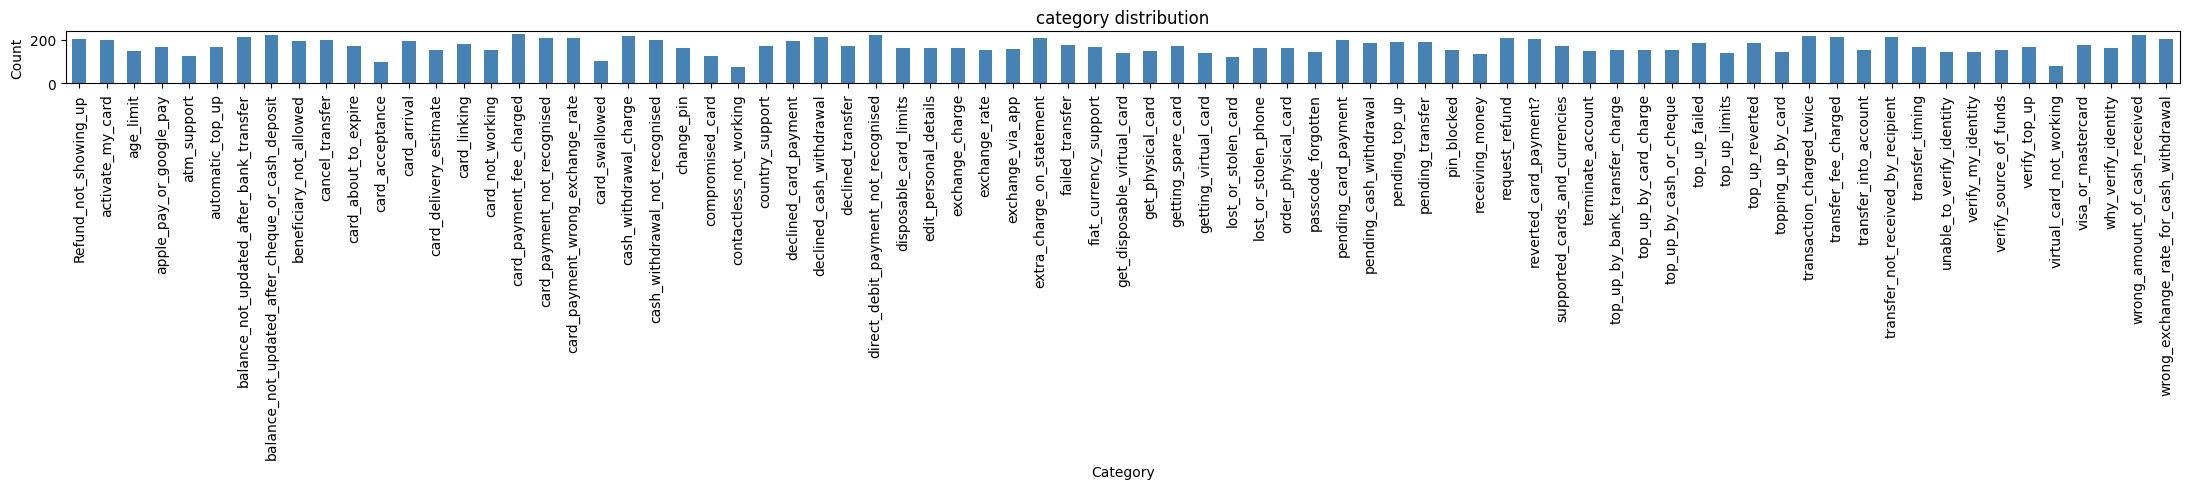

Min samples per category: 75
Max samples per category: 227
Mean samples per class: 169.9


In [44]:
# Class distribution — use a wide figure for 77 classes
category_counts = df_combined['category'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(22, 5))
category_counts.plot.bar(ax=ax, title='category distribution', color='steelblue')
ax.set_xlabel('Category')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print(f'Min samples per category: {category_counts.min()}')
print(f'Max samples per category: {category_counts.max()}')
print(f'Mean samples per class: {category_counts.mean():.1f}')

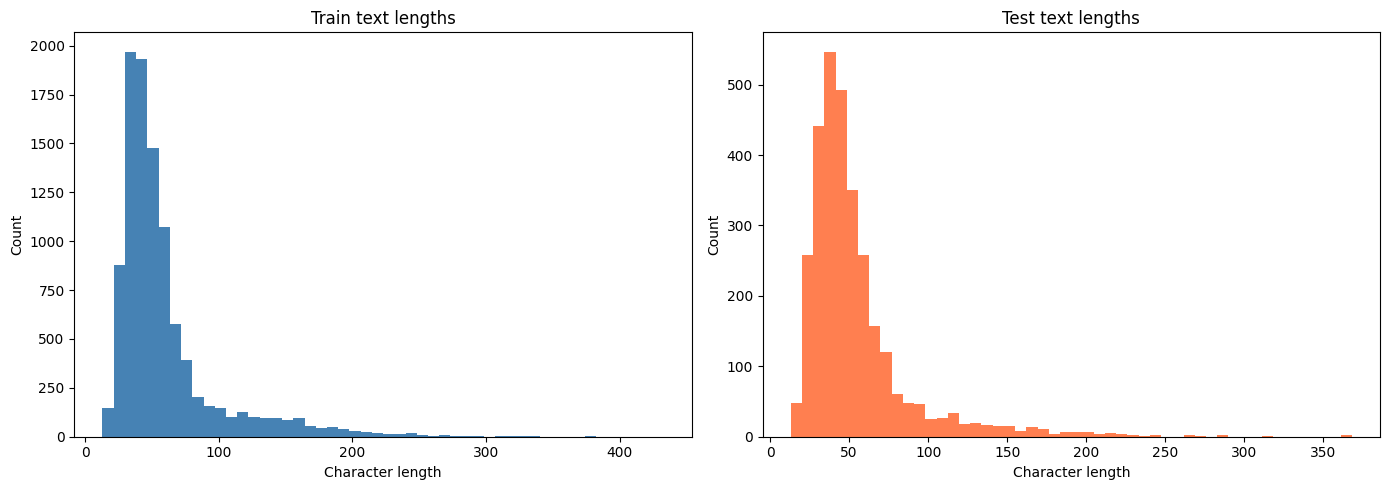

In [46]:
# Text length histograms for train and test sets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_train_raw['text'].str.len().plot.hist(ax=axes[0], title='Train text lengths', bins=50, color='steelblue')
df_test_raw['text'].str.len().plot.hist(ax=axes[1], title='Test text lengths', bins=50, color='coral')
for ax in axes:
    ax.set_xlabel('Character length')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

### Observations
Both Samples seem distributed similarily when it comes to text length and both samples show similar skew and in general distribution of lengths alone seems plausible, we have some outstanding items, very long essays, but most of the texts lie within 100 chars of lengths

I will operate on combined df from now, so i can put it through scikit and cleanlab as well as cleanup duplicates

In [49]:
# check for empty or short strings and these shorter than 5 chars
short_df_combined = df_combined[df_combined['text'].str.len() < 5]
short_df_combined

,text,category


In [51]:
#checking for duplicates in the combined dataset
duplicate_counts = df_combined["text"].groupby(df_combined["text"]).count()
duplicate_counts

,text
text,
What businesses accept this card?,1
At which ATMs can I use this card?,1
Do I need to go to a physical bank to change my PIN?,1
How do I unblock my PIN?,1
I can't seem to be able to use my card,1
...,...
would a visa or mastercard be more suited to me?,1
you got the exchange rate wrong for my cash withdrawal,1
"your company is awful, i would like to delete my account please",1


### Observation
Seems like there are no direct duplicates

In [59]:
df_combined

,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival
...,...,...
13078,"If i'm not in the UK, can I still get a card?",country_support
13079,How many countries do you support?,country_support
13080,What countries do you do business in?,country_support
13081,What are the countries you operate in.,country_support


In [52]:
#seeing if there are multicategory items in the test set that are not in the train set,
#  which would be a problem for evaluation
# i once tried multiclass multilabel classification with minilotto and that was disaster
mlcl_categories = df_combined.groupby('text')['category'].count()

print(f"Number of multilabel items in training set: {(mlcl_categories > 1).sum()}")

Number of multilabel items in training set: 0


In [53]:
#checking for multilabel counts (text with multiple categories)
print(mlcl_categories.sort_values(ascending=False).head(3))

text
€1 was in my statement as an extra fee.    1


What businesses accept this card?        1

At which ATMs can I use this card?        1
Name: category, dtype: int64


### Observations
Either i am doing something wrong or thsi dataset doesnt have any multilabel texts.
Also apparently there is no duplicates as text-category pair 

# 2. Use CleanLab to detect and fix data quality issues:

In [54]:
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import cross_val_predict


def get_initial_model_data(texts: np.ndarray, categorys: np.ndarray) -> tuple:
    """i borrowed thsi function from labs because if it aint broken then dont fix it
    """
    embed_model = SentenceTransformer('all-MiniLM-L6-v2')
    embeddings = embed_model.encode(texts.tolist(), show_progress_bar=True)
    clf = LogisticRegressionCV(max_iter=1000, class_weight='balanced')
    pred_probs = cross_val_predict(clf, embeddings, categorys, method='predict_proba')
    return embeddings, pred_probs

In [55]:
#running on collab so installing cleanlab
try:
    from cleanlab import Datalab
except ModuleNotFoundError:
    !pip install cleanlab
    from cleanlab import Datalab

In [56]:
texts = df_combined['text'].values
categories = df_combined['category'].values

In [57]:
embeddings, pred_probab = get_initial_model_data(texts, categories)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/409 [00:00<?, ?it/s]

In [58]:

data_dict = {"texts": texts, "labels": categories}
lab = Datalab(data_dict, label_name="labels", task="classification")
lab.find_issues(pred_probs=pred_probab, features=embeddings)
lab.report()

Finding null issues ...
Finding label issues ...
Finding outlier issues ...
Finding near_duplicate issues ...
Finding non_iid issues ...
Finding class_imbalance issues ...
Finding underperforming_group issues ...

Audit complete. 878 issues found in the dataset.
Dataset Information: num_examples: 13083, num_classes: 77

Here is a summary of various issues found in your data:

    issue_type  num_issues
near_duplicate         513
         label         200
       outlier         164
       non_iid           1

Learn about each issue: https://docs.cleanlab.ai/stable/cleanlab/datalab/guide/issue_type_description.html
See which examples in your dataset exhibit each issue via: `datalab.get_issues(<ISSUE_NAME>)`

Data indices corresponding to top examples of each issue are shown below.


------------------ near_duplicate issues -------------------

About this issue:
	A (near) duplicate issue refers to two or more examples in
    a dataset that are extremely similar to each other, relative
  

## Near Duplicates

In [60]:
# inspecting near duplicates 
duples = lab.get_issues('near_duplicate')
superduples = duples[duples["is_near_duplicate_issue"] == True]
superduples = superduples.sort_values(by="near_duplicate_score", ascending=False)
superduples

,is_near_duplicate_issue,near_duplicate_score,near_duplicate_sets,distance_to_nearest_neighbor
11866,True,0.121445,[6064],0.010021
6064,True,0.121445,[11866],0.010021
11652,True,0.121302,[5252],0.010008
5252,True,0.121302,[11652],0.010008
11217,True,0.121192,[3901],0.009999
...,...,...,...,...
11435,True,0.000000,[4476],0.000000
12214,True,0.000000,[7169],0.000000
12152,True,0.000000,[6984],0.000000
12301,True,0.000000,[7531],0.000000


In [61]:
superduples.query("is_near_duplicate_issue == True")

,is_near_duplicate_issue,near_duplicate_score,near_duplicate_sets,distance_to_nearest_neighbor
11866,True,0.121445,[6064],0.010021
6064,True,0.121445,[11866],0.010021
11652,True,0.121302,[5252],0.010008
5252,True,0.121302,[11652],0.010008
11217,True,0.121192,[3901],0.009999
...,...,...,...,...
11435,True,0.000000,[4476],0.000000
12214,True,0.000000,[7169],0.000000
12152,True,0.000000,[6984],0.000000
12301,True,0.000000,[7531],0.000000


In [75]:
superduples.sort_values(by="near_duplicate_score", ascending=False)

,is_near_duplicate_issue,near_duplicate_score,near_duplicate_sets,distance_to_nearest_neighbor
6064,True,0.121445,[11866],0.010021
11866,True,0.121445,[6064],0.010021
5252,True,0.121302,[11652],0.010008
11652,True,0.121302,[5252],0.010008
3901,True,0.121192,[11217],0.009999
...,...,...,...,...
4576,True,0.000000,[11477],0.000000
10980,True,0.000000,[3116],0.000000
1290,True,0.000000,[1246],0.000000
1246,True,0.000000,[1290],0.000000


In [73]:
print(texts[13073],"\n", texts[9921])

I don't live in the UK.  Can I still get a card? 
 I don't live in the UK. Can I still get a card?


In [74]:
print(texts[11866],"\n", texts[6064])

What is the cause that the transfer shows as pending? 
 What is the reason why the transfer shows as pending?


In [107]:
# lets print some of the pseudoduples - thsi loop is good so i will keep it
# because otherwise i would need to explode rows in the near_duplicate_sets 
# and this is already elegant solution
duples_to_remove_from_train_and_test = []
ids_first_occurences_to_be_preserved = [] # idx of the first of near of duplicates - soe we will nto remove mutual near duplicates 
ids_of_near_duplicates_to_be_removed = [] # idx of the ids_of_near_duplicates_to_be_removed near duplicates - so we will nto remove mutual near duplicates
zero_distance_duples = superduples[superduples["near_duplicate_score"] == 0]
print(f"Number of zero distance duplicates: {len(zero_distance_duples)}")
for idx, row in zero_distance_duples.iterrows():
    print(f"Processing index: {idx}")
    print("Text: ", texts[idx])
    print("Length of Text: ", len(texts[idx]))
    if idx not in ids_of_near_duplicates_to_be_removed:
        print(f"Item to be added to the first occurences: {idx}")
        text = texts[idx]
        stringies = []
        ids_that_are_duplicates = row["near_duplicate_sets"]
        for idxx in ids_that_are_duplicates:
            if idxx not in ids_first_occurences_to_be_preserved:
                ids_of_near_duplicates_to_be_removed.append(idxx)
                print("Id to Be removed: ", idxx)
                text_to_be_removed = texts[int(idxx)]
                print("Duplicate Text to be removed: ", text_to_be_removed)
                print("Len of Duplicate Text to be removed: ", len(text_to_be_removed))
                stringies.append(text_to_be_removed)
                duples_to_remove_from_train_and_test.append(text_to_be_removed) #this one i will use to clean up these texts from train and test datasets
            else:
                print(f"Id {idxx} is a first occurence, not adding to removal list.")
                print(texts[idxx])  
        ids_first_occurences_to_be_preserved.append(idx)      
    else:
        print(f"Item {idx} is already marked for removal, skipping.")
        print(texts[idx])
        

    print("-" * 69)


Number of zero distance duplicates: 30
Processing index: 3713
Text:  How do I change my address ?
Length of Text:  28
Item to be added to the first occurences: 3713
Id to Be removed:  11161
Duplicate Text to be removed:  How do I change my address?
Len of Duplicate Text to be removed:  27
---------------------------------------------------------------------
Processing index: 3116
Text:  
Where can I use my card?
Length of Text:  25
Item to be added to the first occurences: 3116
Id to Be removed:  10980
Duplicate Text to be removed:  Where can I use my card?
Len of Duplicate Text to be removed:  24
---------------------------------------------------------------------
Processing index: 6984
Text:  
Which cash machines will allow me to change my PIN?
Length of Text:  52
Item to be added to the first occurences: 6984
Id to Be removed:  12152
Duplicate Text to be removed:  Which cash machines will allow me to change my PIN?
Len of Duplicate Text to be removed:  51
--------------------------

I hate whitespaces that are not readili visible on print

In [110]:
print(ids_first_occurences_to_be_preserved)
print(len(ids_first_occurences_to_be_preserved))

[3713, 3116, 6984, 6965, 7531, 1290, 11477, 7169, 10557, 5930, 9921, 4915, 4595, 4476, 11444]
15


In [111]:
print(ids_of_near_duplicates_to_be_removed)
print(len(ids_of_near_duplicates_to_be_removed))

[np.int32(11161), np.int32(10980), np.int32(12152), np.int32(6910), np.int32(12301), np.int32(1246), np.int32(4576), np.int32(12214), np.int32(1722), np.int32(1684), np.int32(1755), np.int32(5922), np.int32(5921), np.int32(11842), np.int32(13073), np.int32(4903), np.int32(4839), np.int32(4594), np.int32(11435), np.int32(11464)]
20


In [112]:
#list of texts that are duplicates - since i havent found any of these existing more than once i will be using them as unique idenifiers for removals 
print(len(duples_to_remove_from_train_and_test))
print(len(set(duples_to_remove_from_train_and_test)))

lower_texts_near_duplicates = [text.lower() for text in duples_to_remove_from_train_and_test]
print(lower_texts_near_duplicates[:5])


20
20
['how do i change my address?', 'where can i use my card?', 'which cash machines will allow me to change my pin?', 'do i need to go to a physical bank to change my pin?', 'the transfer keeps failing , i tried to transfer some money to friends this morning but it keeps getting rejected for some reason, would you please check the issue ?']


In [155]:
# adjust train and test datasets by removing the near duplicates
df_train_cleaned = df_train_raw[~df_train_raw['text'].str.lower().isin(lower_texts_near_duplicates)].reset_index(drop=True)
print(f"Original train set size: {len(df_train_raw)}, Cleaned train set size: {len(df_train_cleaned)}")
df_test_cleaned = df_test_raw[~df_test_raw['text'].str.lower().isin(lower_texts_near_duplicates)].reset_index(drop=True)    
print(f"Original test set size: {len(df_test_raw)}, Cleaned test set size: {len(df_test_cleaned)}")

Original train set size: 10003, Cleaned train set size: 9992
Original test set size: 3080, Cleaned test set size: 3071


### Note:
Not that much of quantitative improvement but at least i wasted some time learning this 

# Observations:
There are some near duplicates in the training set, which could potentially cause issues during training. The most similar pair has a near duplicate score of 0.95, which i assume this means something good. If i can believe documentation, this suggests that the model might struggle to differentiate between these samples, which could lead to overfitting or reduced generalization performance. There are recommendations to reduce size of these

## label issues

In [137]:
label_issues = lab.get_issues("label")

In [138]:
# get these that have is_label_issue = True]
label_issues.query("is_label_issue == True")

,is_label_issue,label_score,given_label,predicted_label
51,True,0.041821,card_arrival,card_delivery_estimate
58,True,0.204006,card_arrival,card_delivery_estimate
75,True,0.062276,card_arrival,card_delivery_estimate
79,True,0.001087,card_arrival,card_delivery_estimate
472,True,0.009515,card_payment_wrong_exchange_rate,exchange_charge
...,...,...,...,...
12697,True,0.163701,balance_not_updated_after_bank_transfer,transfer_not_received_by_recipient
12711,True,0.111197,balance_not_updated_after_bank_transfer,transfer_timing
12714,True,0.002389,balance_not_updated_after_bank_transfer,pending_transfer
12764,True,0.006788,exchange_charge,exchange_rate


In [139]:
for idx, row in label_issues.query("is_label_issue == True").sort_values(by='given_label').iterrows():
    print(f"Index: {idx}")
    print(f"label score: {row['label_score']}")
    print(f"Text: {texts[idx]}")
    print(f"Given Label: {row['given_label']}")
    print(f"Predicted Label: {row['predicted_label']}")
    print("-" * 50)

Index: 9321
label score: 0.0522509970941958
Text: I just got my card and cannot get it to work.
Given Label: activate_my_card
Predicted Label: card_not_working
--------------------------------------------------
Index: 8736
label score: 0.18692439849800888
Text: I transferred some money but it hasn't arrived yet
Given Label: balance_not_updated_after_bank_transfer
Predicted Label: transfer_not_received_by_recipient
--------------------------------------------------
Index: 12690
label score: 0.07356297027021272
Text: When will my transfer be available in my account.
Given Label: balance_not_updated_after_bank_transfer
Predicted Label: transfer_timing
--------------------------------------------------
Index: 12696
label score: 0.1446371712157502
Text: I made a transfer and am still waiting.
Given Label: balance_not_updated_after_bank_transfer
Predicted Label: pending_transfer
--------------------------------------------------
Index: 8765
label score: 0.007960892509879578
Text: How long do

In [140]:
# some of them are very close so i dont know if i can make my jodgment 
# so i will bucket them by 5% jusmp and pick one example from each to compare 
label_issues['label_score_bucket'] = (label_issues['label_score'] // 0.025) * 0.025
MINI = label_issues.query("is_label_issue == True").reset_index().groupby('label_score_bucket').first()[['index', 'label_score', 'given_label', 'predicted_label']]
for idx, row in MINI.iterrows():
    print(f"Index: {row['index']}")
    print(f"text: {texts[row['index']]}")
    print(f"label score: {row['label_score']}")
    print(f"Given Label: {row['given_label']}")
    print(f"Predicted Label: {row['predicted_label']}")
    print("-" * 50)

Index: 79
text: maximum how many days get the courier?
label score: 0.0010870523852466393
Given Label: card_arrival
Predicted Label: card_delivery_estimate
--------------------------------------------------
Index: 51
text: Is there a way I can get my card expedited?
label score: 0.041820913818991376
Given Label: card_arrival
Predicted Label: card_delivery_estimate
--------------------------------------------------
Index: 75
text: How long will it take for me to get my card?
label score: 0.062276416042256665
Given Label: card_arrival
Predicted Label: card_delivery_estimate
--------------------------------------------------
Index: 1072
text: I haven't received my card yet, how long does it normally take?
label score: 0.08245203717897724
Given Label: card_delivery_estimate
Predicted Label: card_arrival
--------------------------------------------------
Index: 644
text: What is this fee debit on my account?
label score: 0.1034427169910798
Given Label: extra_charge_on_statement
Predicted La

### Observation 
After bucketing these i genuinely have no idea if i should change these because most of them are vague at best  but i will do that regardless cause this is funny exercise 

In [145]:
#prepare list there we use text as a key to match test and train datasets and merge to replace labels to the proposed ones by cleanlab
# first we merge the label issues with the original dataframe to get the text and labels together, then we filter for the ones that are label issues and select the relevant columns
text_given_predicted_labels = label_issues.query("is_label_issue == True")[[ 'given_label', 'predicted_label']]
text_given_predicted_labels = text_given_predicted_labels.merge(df_combined, left_index=True, right_index=True)[['text', 'given_label', 'predicted_label']]
text_given_predicted_labels

,text,given_label,predicted_label
51,Is there a way I can get my card expedited?,card_arrival,card_delivery_estimate
58,I know I'm getting a new card but would like k...,card_arrival,card_delivery_estimate
75,How long will it take for me to get my card?,card_arrival,card_delivery_estimate
79,maximum how many days get the courier?,card_arrival,card_delivery_estimate
472,Does the fee for exchange change?,card_payment_wrong_exchange_rate,exchange_charge
...,...,...,...
12697,I made an out of country transfer and it hasn'...,balance_not_updated_after_bank_transfer,transfer_not_received_by_recipient
12711,How long until my transfer will be available t...,balance_not_updated_after_bank_transfer,transfer_timing
12714,My transfer is pending.,balance_not_updated_after_bank_transfer,pending_transfer
12764,whats your exchange rate,exchange_charge,exchange_rate


In [156]:
#now we will merge with previously cleaned datasets to update their corresponding labels to the ones proposed by cleanlab, we will do this for both train and test datasets
# we will use the text as a key to match the rows in the cleaned datasets and update because of index mismatches 
# we will update these dataframes in place and replace value in column category with the proposed label by cleanlab in column predicted_label
df_test_cleaned = df_test_cleaned.merge(text_given_predicted_labels, on='text', how='left')
df_test_cleaned['category'] = df_test_cleaned.apply(lambda row: row['predicted_label'] if pd.notnull(row['predicted_label']) else row['category'], axis=1)

In [158]:
# cleanup 
df_test_cleaned.drop(columns=['given_label', 'predicted_label'], inplace=True)
df_test_cleaned

,text,category
0,How do I locate my card?,card_arrival
1,"I still have not received my new card, I order...",card_arrival
2,I ordered a card but it has not arrived. Help ...,card_arrival
3,Is there a way to know when my card will arrive?,card_arrival
4,My card has not arrived yet.,card_arrival
...,...,...
3066,"If i'm not in the UK, can I still get a card?",country_support
3067,How many countries do you support?,country_support
3068,What countries do you do business in?,country_support
3069,What are the countries you operate in.,country_support


In [159]:
df_train_cleaned = df_train_cleaned.merge(text_given_predicted_labels, on='text', how='left')
df_train_cleaned['category'] = df_train_cleaned.apply(lambda row: row['predicted_label'] if pd.notnull(row['predicted_label']) else row['category'], axis=1)

In [160]:
# cleanup 
df_train_cleaned.drop(columns=['given_label', 'predicted_label'], inplace=True)
df_train_cleaned

,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival
...,...,...
9987,You provide support in what countries?,country_support
9988,What countries are you supporting?,country_support
9989,What countries are getting support?,country_support
9990,Are cards available in the EU?,country_support


## Outliers

In [161]:
outliers = lab.get_issues("outlier")

In [162]:
outliers.query("is_outlier_issue == True")

,is_outlier_issue,outlier_score
79,True,0.035760
93,True,0.005817
146,True,0.045111
296,True,0.054176
367,True,0.054398
...,...,...
13006,True,0.049867
13027,True,0.043687
13054,True,0.029833
13061,True,0.044948


In [168]:
#preview by printing my favourite loop, lets sort them by score
relevant_outliers = outliers.query("is_outlier_issue == True").sort_values(by="outlier_score", ascending=True)
for idx, row in relevant_outliers.iterrows():
    print(f"Index: {idx}")
    print(f"Outlier Score: {row['outlier_score']}")
    print(f"Text: {texts[idx]}")
    print(f"Category: {categories[idx]}")
    print("-" * 50)

Index: 3107
Outlier Score: 0.003152586752548814
Text: WHAT IS THE ATMOSPHERE OF IT
Category: card_acceptance
--------------------------------------------------
Index: 4633
Outlier Score: 0.003974975552409887
Text: what is the word?
Category: direct_debit_payment_not_recognised
--------------------------------------------------
Index: 8802
Outlier Score: 0.004947559908032417
Text: What is this witdrawal
Category: cash_withdrawal_not_recognised
--------------------------------------------------
Index: 4655
Outlier Score: 0.005028645973652601
Text: what is the matter?
Category: direct_debit_payment_not_recognised
--------------------------------------------------
Index: 93
Outlier Score: 0.005817304365336895
Text: WHAT IS THE SOLUTION OF THIS PROBLEM
Category: card_arrival
--------------------------------------------------
Index: 4104
Outlier Score: 0.00741473538801074
Text: I prefer Mastecard.
Category: visa_or_mastercard
--------------------------------------------------
Index: 7432
Out

## Observation 
I am not sure to be honest, its even more vague than the label issue, so i will remove them just in case 


In [177]:
# enrich relevant_outliers with relevant texts
relevant_outliers = relevant_outliers.merge(df_combined[[ 'text', 'category']], left_index=True, right_index=True, how='left')
relevant_outliers

,is_outlier_issue,outlier_score,text,category
3107,True,0.003153,WHAT IS THE ATMOSPHERE OF IT,card_acceptance
4633,True,0.003975,what is the word?,direct_debit_payment_not_recognised
8802,True,0.004948,What is this witdrawal,cash_withdrawal_not_recognised
4655,True,0.005029,what is the matter?,direct_debit_payment_not_recognised
93,True,0.005817,WHAT IS THE SOLUTION OF THIS PROBLEM,card_arrival
...,...,...,...,...
3709,True,0.065163,"Change of location, need to change details",edit_personal_details
10443,True,0.065207,"My entire gym bag, including my wallet, was st...",lost_or_stolen_card
10586,True,0.065464,The NFC payment wouldn't work on the bus today...,contactless_not_working
4718,True,0.065871,"Hi, i was checking my old statements and found...",direct_debit_payment_not_recognised


In [178]:
#remove these outliers by text from both df_cleaned_test and df_cleaned_train
print("Shapes before removing outliers:")
print(f"df_test_cleaned: {df_test_cleaned.shape}")
print(f"df_train_cleaned: {df_train_cleaned.shape}")
df_test_cleaned = df_test_cleaned[~df_test_cleaned['text'].isin(relevant_outliers['text'])]
df_train_cleaned = df_train_cleaned[~df_train_cleaned['text'].isin(relevant_outliers['text'])]
print("Shapes after removing outliers:")
print(f"df_test_cleaned: {df_test_cleaned.shape}")
print(f"df_train_cleaned: {df_train_cleaned.shape}")

Shapes before removing outliers:
df_test_cleaned: (3071, 2)
df_train_cleaned: (9992, 2)
Shapes after removing outliers:
df_test_cleaned: (3039, 2)
df_train_cleaned: (9860, 2)


Thats Fair amount of removal i guess

In [ ]:
#compare length of df_combined with combined leangth of both cleaned datasets to see how much of data we have removed in total
print(f"df_combined: {df_test_raw.shape[0] + df_train_raw.shape[0]}")
print(f"Combined cleaned datasets: {df_test_cleaned.shape[0] + df_train_cleaned.shape[0]}")
print(f"Records relabeled: {len(text_given_predicted_labels)}")
print(f"Records outliers removed: {len(relevant_outliers)}")
flat = [item[0] for sublist in superduples[["near_duplicate_sets"]].values for item in sublist]
flat = list(set(flat))
nearduples_all = superduples.copy(deep=True).reset_index()['index']
nearduples_all
potential_man = [idx for idx in flat if idx not in nearduples_all]
print(len(potential_man))

print(f"Records that could be removed if i removed all of the duplicated: {len(potential_man)}")
print(f"Actual impact is less because some of these issues were overlapping like outliers, label issues etc")

df_combined: 13083
Combined cleaned datasets: 12899
Records relabeled: 200
Records outliers removed: 164
454
Records that could be removed if i removed all of the duplicated: 454


In [195]:
# get these issues that are near_duplicates, label issues and outliers, and see how many of them are overlapping to get a sense of how much data we would remove if we removed all of these issues without looking at them one by one
allforone = lab.get_issues()

In [202]:
allforone.query("is_near_duplicate_issue == True or is_label_issue == True or is_outlier_issue == True")[["is_near_duplicate_issue", "is_label_issue", "is_outlier_issue"]]
#actually there is none that has three at once

,is_near_duplicate_issue,is_label_issue,is_outlier_issue
26,True,False,False
29,True,False,False
51,False,True,False
58,False,True,False
75,False,True,False
...,...,...,...
13054,False,False,True
13058,True,False,False
13061,False,False,True
13067,False,False,True


### Observations
My poor attempt at data cleanup turned out to remove small portion of data compared to papre, only less, than 100 records, compared to 1400 that authors promise contain errors 
in our case it might be driven by the fact that removal was the only thing we didm as we updated 200 of them so we coudl have said that thsi is driven by the fact that i gave put limiters on the  removed duplicates, i only removed these (15) that were extremely similar because i find the overlapping duplicates not semantically close as native speaker would, especially when labels are not as self explanatory in some cases 

